# Energy Consumption Analysis

## Project aim

This notebook analyses `energy_consumption.csv` using Python. The workflow covers data inspection, preprocessing, exploratory data analysis, and hypothesis testing to identify factors associated with recorded energy cost.

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
import itertools

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

## 1. Data loading and initial data-quality checks

**Method used:**  
We first loaded the dataset and checked its size, structure, data types, missing values, duplicate rows, and descriptive statistics. This step is important because data quality problems can distort the results of later analysis.

**Why this matters:**  
Before interpreting patterns, we need to confirm that the dataset is reliable and that each variable is understood correctly.


In [2]:
# 2. Load Dataset
df_raw = pd.read_csv("energy_consumption.csv")

print("Dataset loaded successfully.")
print(f"Rows: {df_raw.shape[0]}")
print(f"Columns: {df_raw.shape[1]}")

print("\nFirst 5 rows:")
display(df_raw.head())

Dataset loaded successfully.
Rows: 5000
Columns: 6

First 5 rows:


,customer_id,customer_type,regions,building_size_m2,occupants,energy_cost_brl
0,CUSTOMER_0001,residential,Northeast,24,2,64.51
1,CUSTOMER_0002,commercial,Midwest,24,1,55.26
2,CUSTOMER_0003,commercial,Southeast,24,1,74.54
3,CUSTOMER_0004,residential,Northeast,45,4,147.06
4,CUSTOMER_0005,residential,Southeast,45,4,143.06


In [3]:
# 3. Initial inspection
print("\nDataset information:")
df_raw.info()

print("\nMissing values by column:")
display(df_raw.isnull().sum().to_frame("missing_values"))

print(f"\nDuplicate rows: {df_raw.duplicated().sum()}")

print("\nDescriptive statistics:")


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       5000 non-null   object 
 1   customer_type     5000 non-null   object 
 2   regions           5000 non-null   object 
 3   building_size_m2  5000 non-null   int64  
 4   occupants         5000 non-null   int64  
 5   energy_cost_brl   5000 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 234.5+ KB

Missing values by column:


,missing_values
customer_id,0
customer_type,0
regions,0
building_size_m2,0
occupants,0
energy_cost_brl,0



Duplicate rows: 0

Descriptive statistics:


## 2. Preprocessing design
Method used:
We created a separate analysis copy of the dataset and removed customer_id from the analytical dataset because it is only an identifier, not a meaningful explanatory variable.

Important preprocessing decision:
Potential outliers were reviewed, but they were not removed automatically. In this dataset, building_size_m2 and occupants contain valid discrete values, so using automatic IQR deletion could incorrectly remove genuine observations and weaken the analysis.

In [4]:
#  4. Create analysis copy

# Keep the raw dataset unchanged
df = df_raw.copy()

# customer_id is just an identifier, so it is removed from the analysis dataset
df_analysis = df.drop(columns=["customer_id"])

categorical_cols = ["customer_type", "regions"]
numerical_cols = ["building_size_m2", "occupants", "energy_cost_brl"]

print("\nUnique values in categorical columns:")
for col in categorical_cols:
    print(f"{col}: {df_analysis[col].unique()}")

print("\nUnique values in selected numerical columns:")
for col in ["building_size_m2", "occupants"]:
    print(f"{col}: {sorted(df_analysis[col].unique())}")


Unique values in categorical columns:
customer_type: ['residential' 'commercial']
regions: ['Northeast' 'Midwest' 'Southeast' 'North' 'South']

Unique values in selected numerical columns:
building_size_m2: [np.int64(17), np.int64(24), np.int64(45), np.int64(52), np.int64(77)]
occupants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [5]:
# 5. Frequency tables
print("\nCustomer type counts:")
display(df_analysis["customer_type"].value_counts().to_frame("count"))

print("\nRegion counts:")
display(df_analysis["regions"].value_counts().to_frame("count"))

print("\nBuilding size counts:")
display(df_analysis["building_size_m2"].value_counts().sort_index().to_frame("count"))

print("\nOccupant counts:")
display(df_analysis["occupants"].value_counts().sort_index().to_frame("count"))


Customer type counts:


,count
customer_type,
residential,3261
commercial,1739



Region counts:


,count
regions,
Midwest,2012
Northeast,1266
North,759
South,482
Southeast,481



Building size counts:


,count
building_size_m2,
17,744
24,1249
45,1976
52,522
77,509



Occupant counts:


,count
occupants,
1,1386
2,1472
3,1389
4,753


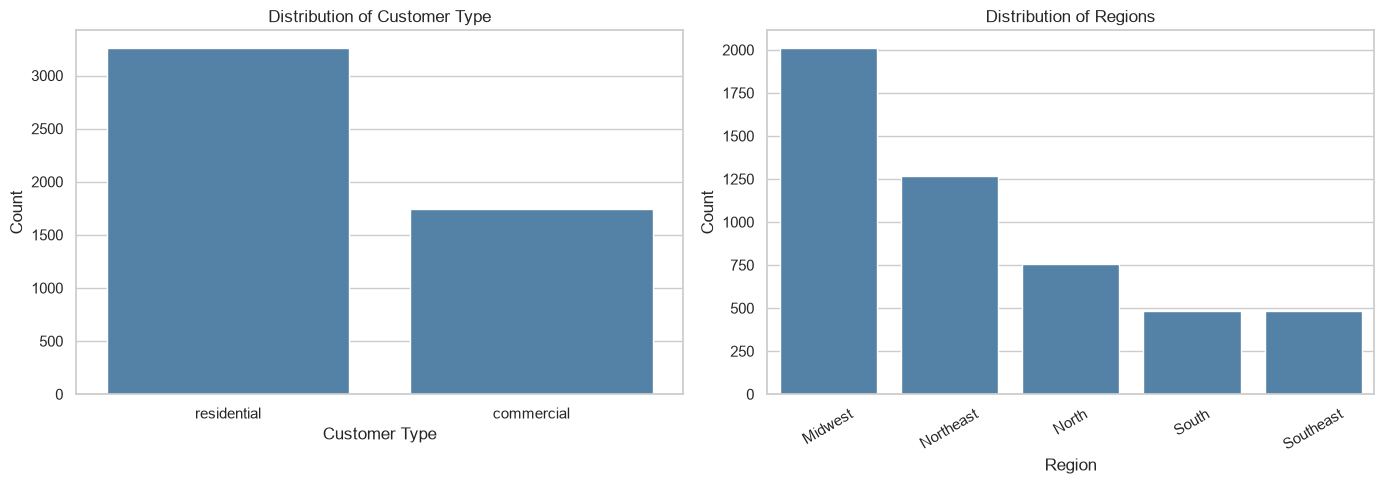

In [6]:
# 6. Categorical distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_analysis, x="customer_type", ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Customer Type")
axes[0].set_xlabel("Customer Type")
axes[0].set_ylabel("Count")

sns.countplot(
    data=df_analysis,
    x="regions",
    order=df_analysis["regions"].value_counts().index,
    ax=axes[1],
    color="steelblue"
)
axes[1].set_title("Distribution of Regions")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

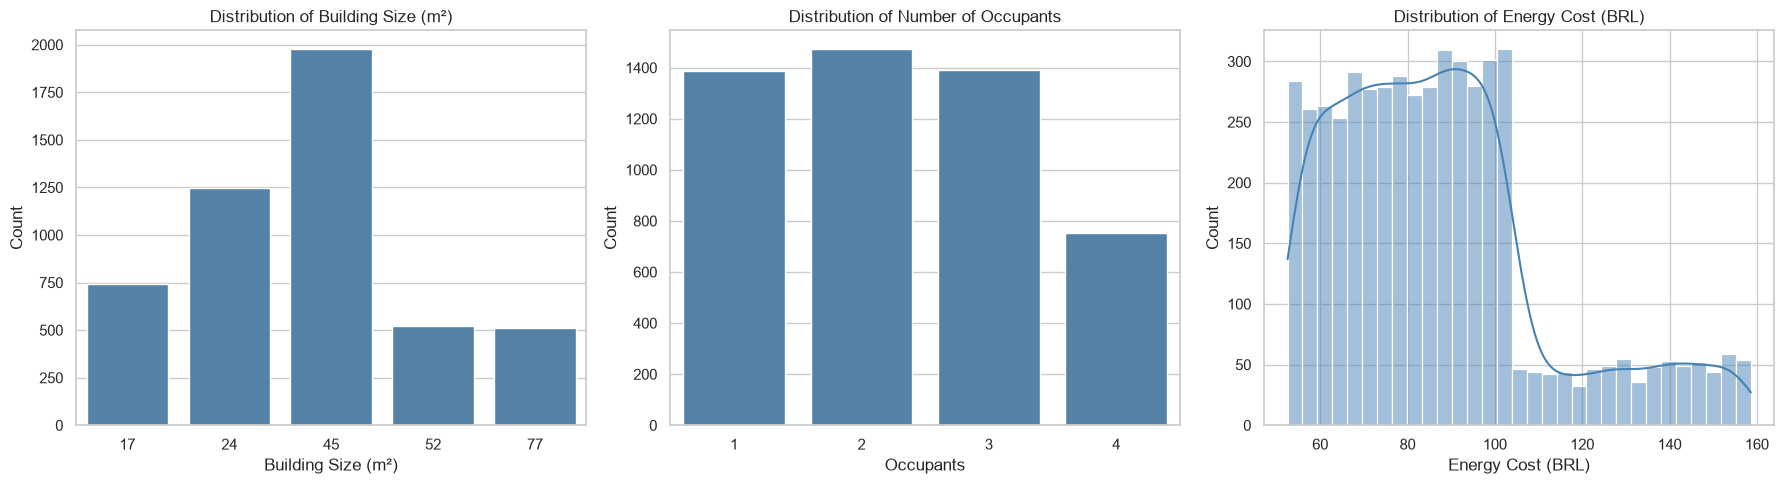

In [7]:
# 7. Numerical distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# building_size_m2 contains discrete size categories, so countplot is clearer than histplot
sns.countplot(
    data=df_analysis,
    x="building_size_m2",
    order=sorted(df_analysis["building_size_m2"].unique()),
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Distribution of Building Size (m²)")
axes[0].set_xlabel("Building Size (m²)")
axes[0].set_ylabel("Count")

# occupants also contains discrete values, so countplot is more appropriate
sns.countplot(
    data=df_analysis,
    x="occupants",
    order=sorted(df_analysis["occupants"].unique()),
    ax=axes[1],
    color="steelblue"
)
axes[1].set_title("Distribution of Number of Occupants")
axes[1].set_xlabel("Occupants")
axes[1].set_ylabel("Count")

# energy_cost_brl is continuous, so histplot remains appropriate
sns.histplot(
    data=df_analysis,
    x="energy_cost_brl",
    kde=True,
    ax=axes[2],
    color="steelblue"
)
axes[2].set_title("Distribution of Energy Cost (BRL)")
axes[2].set_xlabel("Energy Cost (BRL)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

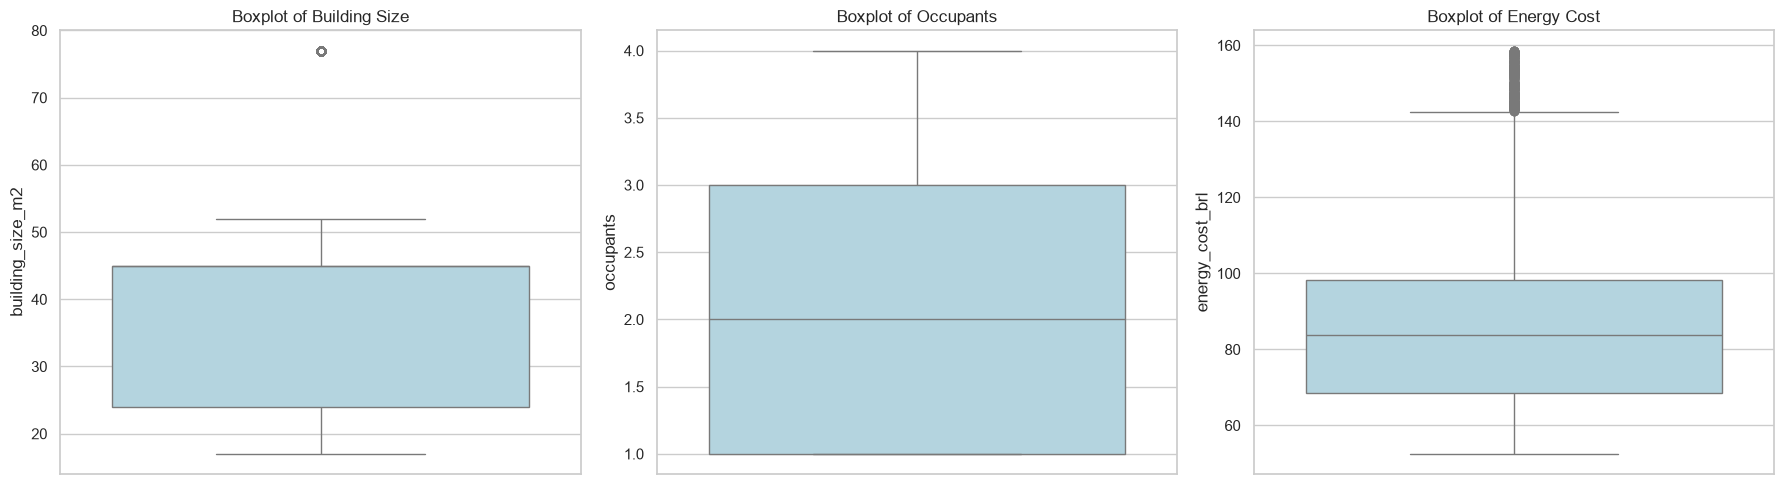

In [8]:
# 8. Boxplots for numerical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_analysis, y="building_size_m2", ax=axes[0], color="lightblue")
axes[0].set_title("Boxplot of Building Size")

sns.boxplot(data=df_analysis, y="occupants", ax=axes[1], color="lightblue")
axes[1].set_title("Boxplot of Occupants")

sns.boxplot(data=df_analysis, y="energy_cost_brl", ax=axes[2], color="lightblue")
axes[2].set_title("Boxplot of Energy Cost")

plt.tight_layout()
plt.show()


In [9]:
# 9. Outlier review only
# Outliers are checked but not removed automatically.
# This is important because building_size_m2 and occupants are discrete valid values.
print("Potential outlier check using IQR (for review only):\n")

for col in numerical_cols:
    Q1 = df_analysis[col].quantile(0.25)
    Q3 = df_analysis[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = ((df_analysis[col] < lower_bound) | (df_analysis[col] > upper_bound)).sum()

    print(f"{col}")
    print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"Lower bound = {lower_bound:.2f}, Upper bound = {upper_bound:.2f}")
    print(f"Potential outliers = {outlier_count}")
    print("-" * 50)

print("""
Decision:
Potential outliers were reviewed but not removed automatically.
This prevents valid discrete categories from being deleted incorrectly.
""")

Potential outlier check using IQR (for review only):

building_size_m2
Q1 = 24.00, Q3 = 45.00, IQR = 21.00
Lower bound = -7.50, Upper bound = 76.50
Potential outliers = 509
--------------------------------------------------
occupants
Q1 = 1.00, Q3 = 3.00, IQR = 2.00
Lower bound = -2.00, Upper bound = 6.00
Potential outliers = 0
--------------------------------------------------
energy_cost_brl
Q1 = 68.56, Q3 = 98.24, IQR = 29.68
Lower bound = 24.03, Upper bound = 142.77
Potential outliers = 242
--------------------------------------------------

Decision:
Potential outliers were reviewed but not removed automatically.
This prevents valid discrete categories from being deleted incorrectly.



## 3. Exploratory data analysis
**Method used:**
We combined summary tables, count plots, histograms, boxplots, bar plots, and group-level descriptive statistics. This allows both the overall distribution of the data and the differences between subgroups to be seen clearly.

**Findings to look for in this section:**

* whether some categories dominate the dataset
* whether energy cost is similarly distributed across groups
* which variables seem to show the strongest visible relationship with energy cost

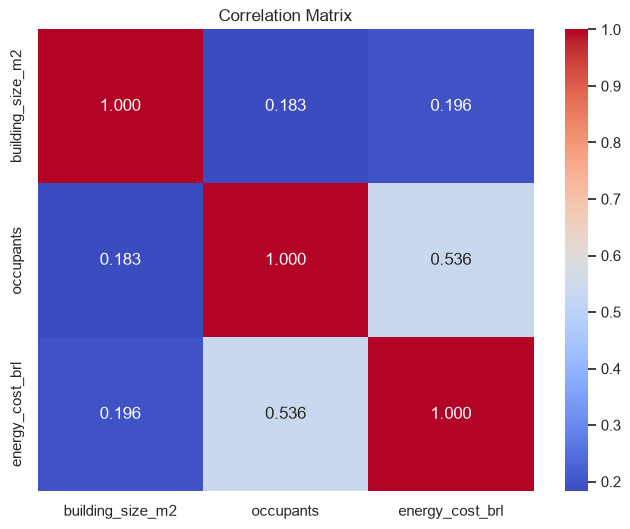

In [10]:
# 10. Correlation analysis
corr = df_analysis[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Matrix")
plt.show()

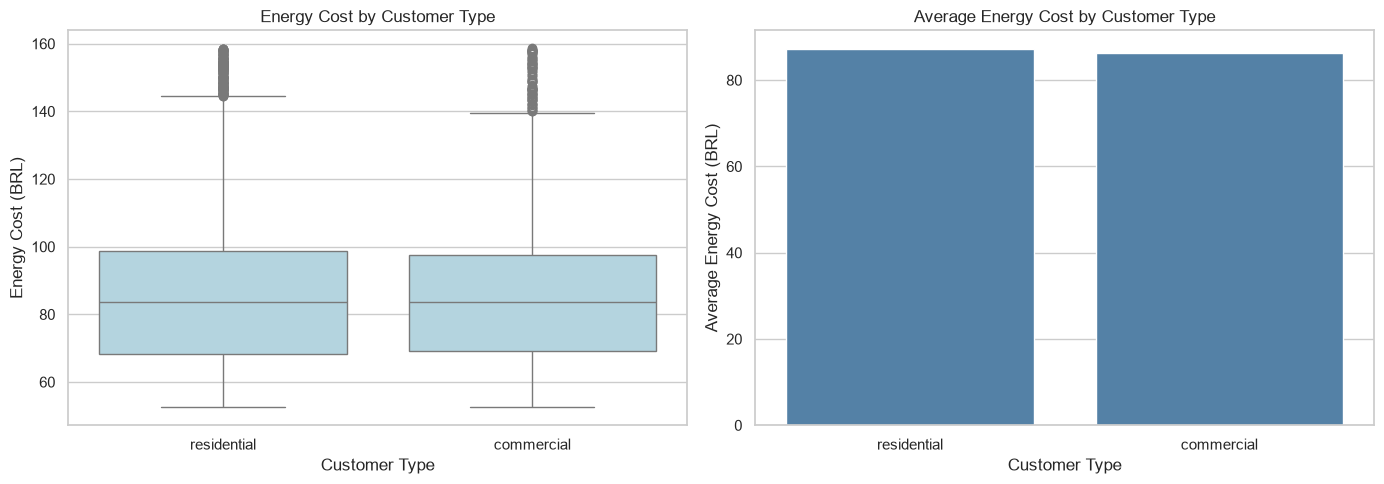

In [11]:
# 11. Energy cost by customer type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_analysis, x="customer_type", y="energy_cost_brl", ax=axes[0], color="lightblue")
axes[0].set_title("Energy Cost by Customer Type")
axes[0].set_xlabel("Customer Type")
axes[0].set_ylabel("Energy Cost (BRL)")

customer_mean = (
    df_analysis.groupby("customer_type")["energy_cost_brl"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(data=customer_mean, x="customer_type", y="energy_cost_brl", ax=axes[1], color="steelblue")
axes[1].set_title("Average Energy Cost by Customer Type")
axes[1].set_xlabel("Customer Type")
axes[1].set_ylabel("Average Energy Cost (BRL)")

plt.tight_layout()
plt.show()

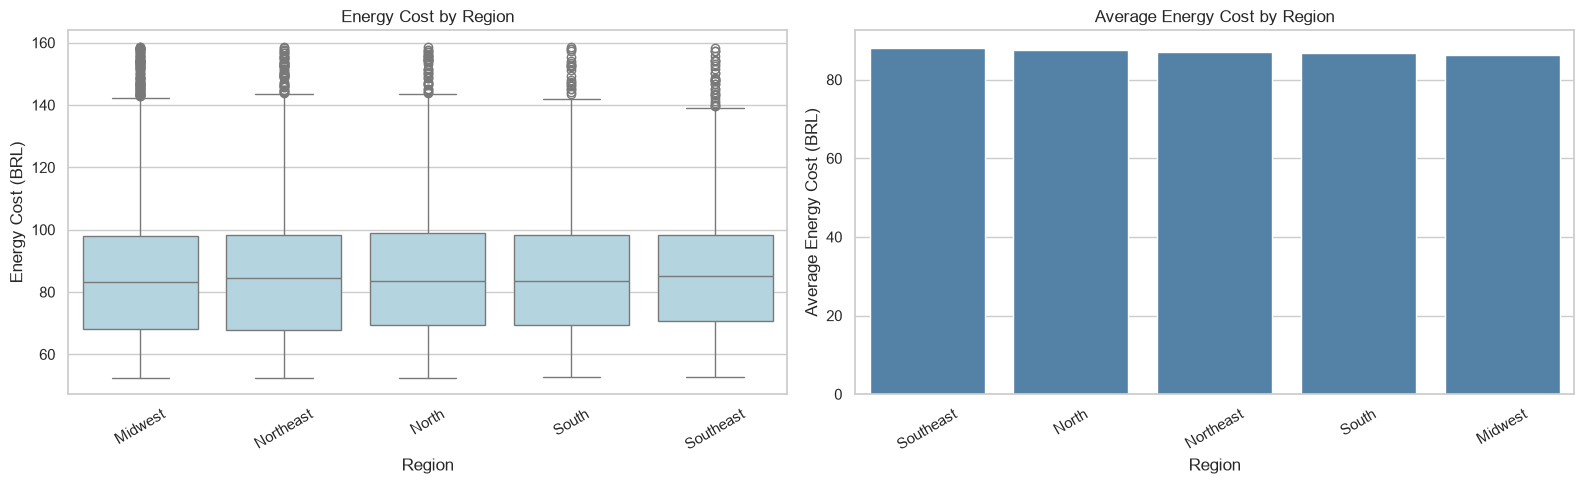

In [12]:
# 12. Energy cost by region
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

region_order = df_analysis["regions"].value_counts().index

sns.boxplot(data=df_analysis, x="regions", y="energy_cost_brl", order=region_order, ax=axes[0], color="lightblue")
axes[0].set_title("Energy Cost by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Energy Cost (BRL)")
axes[0].tick_params(axis="x", rotation=30)

region_mean = (
    df_analysis.groupby("regions")["energy_cost_brl"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(data=region_mean, x="regions", y="energy_cost_brl", order=region_mean["regions"], ax=axes[1], color="steelblue")
axes[1].set_title("Average Energy Cost by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Average Energy Cost (BRL)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


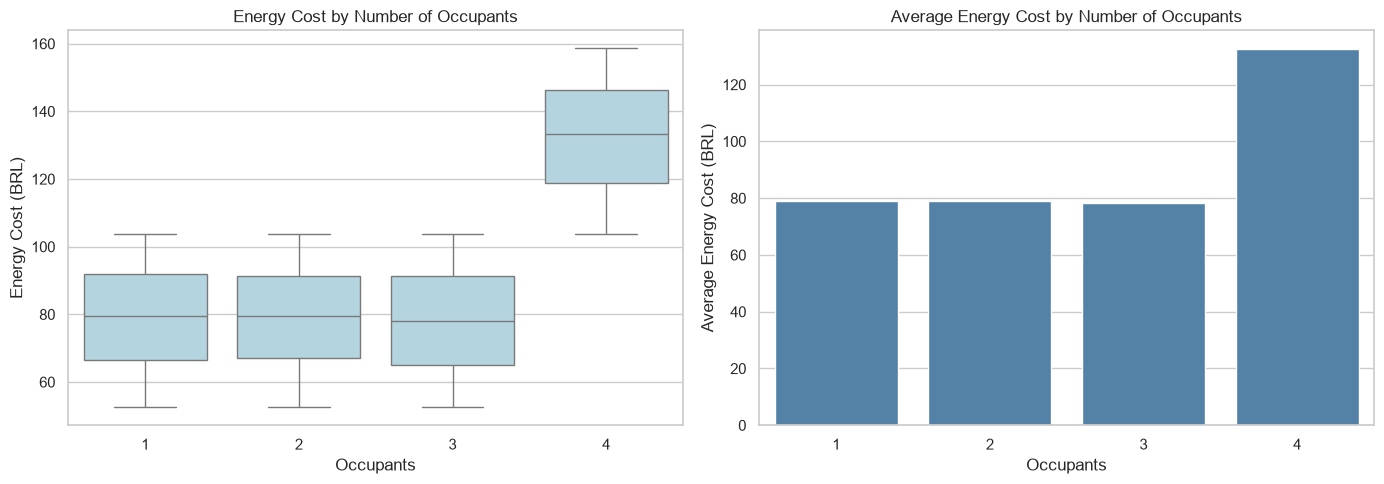

In [13]:
# 13. Energy cost by occupants
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_analysis, x="occupants", y="energy_cost_brl", ax=axes[0], color="lightblue")
axes[0].set_title("Energy Cost by Number of Occupants")
axes[0].set_xlabel("Occupants")
axes[0].set_ylabel("Energy Cost (BRL)")

occupant_mean = (
    df_analysis.groupby("occupants")["energy_cost_brl"]
    .mean()
    .reset_index()
)

sns.barplot(data=occupant_mean, x="occupants", y="energy_cost_brl", ax=axes[1], color="steelblue")
axes[1].set_title("Average Energy Cost by Number of Occupants")
axes[1].set_xlabel("Occupants")
axes[1].set_ylabel("Average Energy Cost (BRL)")

plt.tight_layout()
plt.show()


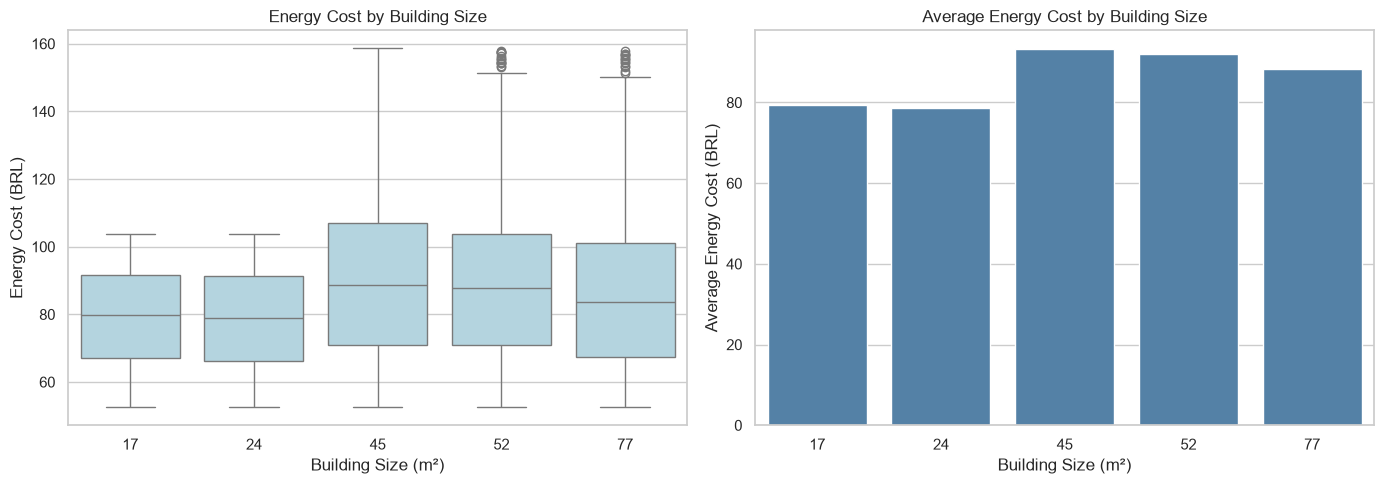

In [14]:
# 14. Energy cost by building size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_analysis, x="building_size_m2", y="energy_cost_brl", ax=axes[0], color="lightblue")
axes[0].set_title("Energy Cost by Building Size")
axes[0].set_xlabel("Building Size (m²)")
axes[0].set_ylabel("Energy Cost (BRL)")

size_mean = (
    df_analysis.groupby("building_size_m2")["energy_cost_brl"]
    .mean()
    .reset_index()
)

sns.barplot(data=size_mean, x="building_size_m2", y="energy_cost_brl", ax=axes[1], color="steelblue")
axes[1].set_title("Average Energy Cost by Building Size")
axes[1].set_xlabel("Building Size (m²)")
axes[1].set_ylabel("Average Energy Cost (BRL)")

plt.tight_layout()
plt.show()

In [15]:
# 15. Summary tables
print("\nAverage energy cost by region:")
display(
    df_analysis.groupby("regions")["energy_cost_brl"]
    .agg(["mean", "median", "min", "max"])
    .sort_values(by="mean", ascending=False)
)

print("\nAverage energy cost by customer type:")
display(
    df_analysis.groupby("customer_type")["energy_cost_brl"]
    .agg(["mean", "median", "min", "max"])
    .sort_values(by="mean", ascending=False)
)

print("\nAverage energy cost by occupants:")
display(
    df_analysis.groupby("occupants")["energy_cost_brl"]
    .agg(["mean", "median", "min", "max"])
    .sort_values(by="mean", ascending=False)
)

print("\nAverage energy cost by building size:")
display(
    df_analysis.groupby("building_size_m2")["energy_cost_brl"]
    .agg(["mean", "median", "min", "max"])
    .sort_values(by="mean", ascending=False)
)


Average energy cost by region:


,mean,median,min,max
regions,,,,
Southeast,88.10,85.25,52.80,158.19
North,87.59,83.65,52.52,158.51
Northeast,86.93,84.49,52.53,158.45
South,86.74,83.62,52.70,158.61
Midwest,86.31,83.21,52.53,158.52



Average energy cost by customer type:


,mean,median,min,max
customer_type,,,,
residential,87.15,83.78,52.52,158.52
commercial,86.35,83.63,52.64,158.61



Average energy cost by occupants:


,mean,median,min,max
occupants,,,,
4,132.44,133.38,103.86,158.61
1,79.15,79.47,52.53,103.84
2,78.91,79.37,52.52,103.84
3,78.31,77.91,52.55,103.81



Average energy cost by building size:


,mean,median,min,max
building_size_m2,,,,
45,93.19,88.60,52.53,158.61
52,92.13,87.69,52.63,157.78
77,88.35,83.55,52.52,157.83
17,79.27,79.76,52.53,103.84
24,78.61,78.92,52.55,103.84


## 4. Hypothesis testing
**Method used:**
We used hypothesis testing to evaluate whether group differences in energy cost were statistically significant.

*  For customer type, we used a Welch independent-samples t-test because there are two groups and Welch's version is more robust when variances are not equal.
*  For region, occupants, and building size, we used one-way ANOVA to test for mean differences across more than two groups.
*  We also checked Levene's test for variance homogeneity and added Kruskal–Wallis as a robustness check for the multi-group factors.

**Why this strengthens the work:**

This makes the analysis more academically defensible because we are not relying on only one significance test without checking whether the assumptions are reasonable.

In [16]:
# 16. Statistical tests
print("Assumption checks and statistical testing results:\n")

# Helper function for Levene's test
def levene_by_factor(data, factor, target="energy_cost_brl"):
    groups = [group[target].values for _, group in data.groupby(factor)]
    stat, p = stats.levene(*groups, center="median")
    return stat, p

# 16.1 Customer type -> Welch t-test
residential = df_analysis[df_analysis["customer_type"] == "residential"]["energy_cost_brl"]
commercial = df_analysis[df_analysis["customer_type"] == "commercial"]["energy_cost_brl"]

levene_customer_stat, levene_customer_p = stats.levene(residential, commercial, center="median")
t_stat, p_val_customer = stats.ttest_ind(residential, commercial, equal_var=False)

print("Customer type")
print(f"Levene p-value: {levene_customer_p:.4f}")
print(f"Welch t-test p-value: {p_val_customer:.4f}")
print("-" * 60)

# 16.2 Region -> ANOVA + Kruskal-Wallis
region_groups = [group["energy_cost_brl"].values for _, group in df_analysis.groupby("regions")]
levene_region_stat, levene_region_p = stats.levene(*region_groups, center="median")
f_region, p_val_region = stats.f_oneway(*region_groups)
kw_region_stat, kw_region_p = stats.kruskal(*region_groups)

print("Region")
print(f"Levene p-value: {levene_region_p:.4f}")
print(f"ANOVA p-value: {p_val_region:.4f}")
print(f"Kruskal-Wallis p-value: {kw_region_p:.4f}")
print("-" * 60)

# 16.3 Occupants -> ANOVA + Kruskal-Wallis
occupant_groups = [group["energy_cost_brl"].values for _, group in df_analysis.groupby("occupants")]
levene_occupants_stat, levene_occupants_p = stats.levene(*occupant_groups, center="median")
f_occupants, p_val_occupants = stats.f_oneway(*occupant_groups)
kw_occupants_stat, kw_occupants_p = stats.kruskal(*occupant_groups)

print("Occupants")
print(f"Levene p-value: {levene_occupants_p:.4e}")
print(f"ANOVA p-value: {p_val_occupants:.4e}")
print(f"Kruskal-Wallis p-value: {kw_occupants_p:.4e}")
print("-" * 60)

# 16.4 Building size -> ANOVA + Kruskal-Wallis
size_groups = [group["energy_cost_brl"].values for _, group in df_analysis.groupby("building_size_m2")]
levene_size_stat, levene_size_p = stats.levene(*size_groups, center="median")
f_size, p_val_size = stats.f_oneway(*size_groups)
kw_size_stat, kw_size_p = stats.kruskal(*size_groups)

print("Building size")
print(f"Levene p-value: {levene_size_p:.4e}")
print(f"ANOVA p-value: {p_val_size:.4e}")
print(f"Kruskal-Wallis p-value: {kw_size_p:.4e}")

Assumption checks and statistical testing results:

Customer type
Levene p-value: 0.0069
Welch t-test p-value: 0.2618
------------------------------------------------------------
Region
Levene p-value: 0.5299
ANOVA p-value: 0.5612
Kruskal-Wallis p-value: 0.6050
------------------------------------------------------------
Occupants
Levene p-value: 2.0318e-03
ANOVA p-value: 0.0000e+00
Kruskal-Wallis p-value: 0.0000e+00
------------------------------------------------------------
Building size
Levene p-value: 2.3793e-102
ANOVA p-value: 6.9368e-83
Kruskal-Wallis p-value: 1.6091e-49


In [17]:
# 17. Pairwise follow-up for occupants (Bonferroni-adjusted Mann-Whitney U)
# This helps identify which occupant groups differ after finding a significant overall result.
pairs = list(itertools.combinations(sorted(df_analysis["occupants"].unique()), 2))
pairwise_results = []

for a, b in pairs:
    group_a = df_analysis[df_analysis["occupants"] == a]["energy_cost_brl"]
    group_b = df_analysis[df_analysis["occupants"] == b]["energy_cost_brl"]

    u_stat, p_val = stats.mannwhitneyu(group_a, group_b, alternative="two-sided")
    pairwise_results.append({
        "comparison": f"{a} vs {b}",
        "raw_p_value": p_val
    })

pairwise_df = pd.DataFrame(pairwise_results)
pairwise_df["bonferroni_p_value"] = (pairwise_df["raw_p_value"] * len(pairwise_df)).clip(upper=1.0)
pairwise_df["significant_at_0_05"] = pairwise_df["bonferroni_p_value"] < 0.05

# Önce sayısal olarak sırala
pairwise_df_sorted = pairwise_df.sort_values("bonferroni_p_value").reset_index(drop=True)

# Sonra sadece gösterim için kopya oluştur
pairwise_df_display = pairwise_df_sorted.copy()
pairwise_df_display["raw_p_value"] = pairwise_df_display["raw_p_value"].apply(
    lambda x: "< 0.0001" if x < 0.0001 else f"{x:.4f}"
)
pairwise_df_display["bonferroni_p_value"] = pairwise_df_display["bonferroni_p_value"].apply(
    lambda x: "< 0.0001" if x < 0.0001 else f"{x:.4f}"
)

print("Pairwise comparisons for occupants:")
display(pairwise_df_display)

Pairwise comparisons for occupants:


,comparison,raw_p_value,bonferroni_p_value,significant_at_0_05
0,1 vs 4,< 0.0001,< 0.0001,True
1,2 vs 4,< 0.0001,< 0.0001,True
2,3 vs 4,< 0.0001,< 0.0001,True
3,1 vs 3,0.1490,0.8939,False
4,1 vs 2,0.6484,1.0000,False
5,2 vs 3,0.2931,1.0000,False


## 5. Interpretation of the main statistical results
**Key interpretation:**
*  Customer type does not show a statistically meaningful difference in energy cost.
*  Region also does not show a statistically meaningful difference.
*  Occupants show a very strong and statistically significant difference, and the follow-up tests indicate that the 4-occupant group is the main source of that difference.
*  Building size also shows a statistically significant relationship with energy cost, although the pattern is not perfectly linear across all building sizes.

This is an academically stronger interpretation than simply saying "bigger is always higher" or "all groups are different", because it reflects the actual statistical evidence more carefully.

In [18]:
# 18. Final conclusions
insight_table = pd.DataFrame({
    "Factor": ["Customer Type", "Region", "Occupants", "Building Size"],
    "Main Result": [
        "Residential and commercial customers have very similar average energy costs.",
        "Regional differences exist descriptively, but the statistical evidence is weak.",
        "Properties with 4 occupants have much higher energy costs than the other groups.",
        "Building size is associated with energy cost, but the pattern is not perfectly linear."
    ],
    "Primary Test": [
        "Welch t-test",
        "ANOVA + Kruskal-Wallis",
        "ANOVA + Kruskal-Wallis + pairwise Mann-Whitney U",
        "ANOVA + Kruskal-Wallis"
    ],
    "Result Summary": [
        f"p = {p_val_customer:.4f}",
        f"ANOVA p = {p_val_region:.4f}; KW p = {kw_region_p:.4f}",
        f"ANOVA p = {p_val_occupants:.4e}; KW p = {kw_occupants_p:.4e}",
        f"ANOVA p = {p_val_size:.4e}; KW p = {kw_size_p:.4e}"
    ]
})

print("\nInsight summary table:")
display(insight_table)


Insight summary table:


,Factor,Main Result,Primary Test,Result Summary
0,Customer Type,Residential and commercial customers have very...,Welch t-test,p = 0.2618
1,Region,"Regional differences exist descriptively, but ...",ANOVA + Kruskal-Wallis,ANOVA p = 0.5612; KW p = 0.6050
2,Occupants,Properties with 4 occupants have much higher e...,ANOVA + Kruskal-Wallis + pairwise Mann-Whitney U,ANOVA p = 0.0000e+00; KW p = 0.0000e+00
3,Building Size,"Building size is associated with energy cost, ...",ANOVA + Kruskal-Wallis,ANOVA p = 6.9368e-83; KW p = 1.6091e-49


In [19]:
# 19. Final academic conclusion
print("""
Final conclusion:
1. The dataset is suitable for analysis because it contains no missing values and no duplicate rows.
2. customer_id was excluded from the analytical dataset because it is only an identifier and does not explain energy cost.
3. Potential outliers were reviewed but not removed automatically, since the dataset contains valid discrete categories and deleting them could remove genuine observations.
4. Descriptive analysis and statistical testing both show that the number of occupants is the strongest practical factor associated with energy cost.
5. In particular, the 4-occupant group has substantially higher energy costs than the 1-, 2-, and 3-occupant groups.
6. Building size also has a statistically significant relationship with energy cost, but the pattern is not perfectly linear across all size categories.
7. By contrast, customer type and region show only small differences and do not appear to be strong drivers of energy cost in this dataset.
8. Overall, the most important practical drivers of energy cost in this dataset are occupancy level and, to a lesser extent, building size.
""")



Final conclusion:
1. The dataset is suitable for analysis because it contains no missing values and no duplicate rows.
2. customer_id was excluded from the analytical dataset because it is only an identifier and does not explain energy cost.
3. Potential outliers were reviewed but not removed automatically, since the dataset contains valid discrete categories and deleting them could remove genuine observations.
4. Descriptive analysis and statistical testing both show that the number of occupants is the strongest practical factor associated with energy cost.
5. In particular, the 4-occupant group has substantially higher energy costs than the 1-, 2-, and 3-occupant groups.
6. Building size also has a statistically significant relationship with energy cost, but the pattern is not perfectly linear across all size categories.
7. By contrast, customer type and region show only small differences and do not appear to be strong drivers of energy cost in this dataset.
8. Overall, the most imp